In [1]:
from pathlib import Path
import pandas as pd

RUN_DIR = Path("runs/2026-01-15_141249")   # <-- change to your run folder
BASE = RUN_DIR / "per_model"

dfs = []
for model_dir in sorted(BASE.iterdir()):
    csv_path = model_dir / "ablation_metrics.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        # ensure model_tag exists (some scripts already include it)
        if "model_tag" not in df.columns:
            df["model_tag"] = model_dir.name
        dfs.append(df)

all_df = pd.concat(dfs, ignore_index=True)
all_df.head(), all_df.shape


(              experiment          learner          cv  \
 0      M1_no_interaction  dcpl_gate=ridge  split80_20   
 1       M2a_add_AIxNonAI  dcpl_gate=ridge  split80_20   
 2  M2b_add_AIxN_and_AIxW  dcpl_gate=ridge  split80_20   
 3                M3_full  dcpl_gate=ridge  split80_20   
 4      M1_no_interaction  dcpl_gate=ridge  split80_20   
 
                              target                     model_tag  n_train  \
 0  Target_throughput_tokens_per_sec  data_EleutherAI_gpt-neox-20b    71775   
 1  Target_throughput_tokens_per_sec  data_EleutherAI_gpt-neox-20b    71775   
 2  Target_throughput_tokens_per_sec  data_EleutherAI_gpt-neox-20b    71775   
 3  Target_throughput_tokens_per_sec  data_EleutherAI_gpt-neox-20b    71775   
 4                 Target_latency_ms  data_EleutherAI_gpt-neox-20b    71775   
 
    n_test        R2          MAE         RMSE         MRE       ΔR2      ΔMAE  \
 0   17944  0.109594   217.189229   551.210485  370.393234  0.000000  0.000000   
 1   17944

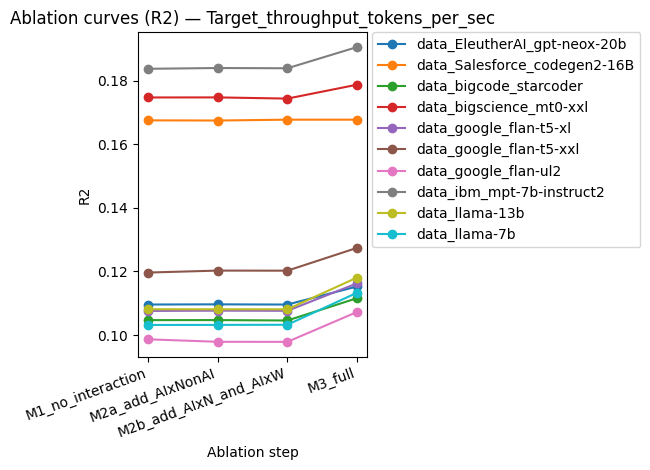

In [2]:
import matplotlib.pyplot as plt

TARGET = "Target_throughput_tokens_per_sec"  # <-- change target here if needed

df_t = all_df[all_df["target"] == TARGET].copy()

plt.figure()
for model_tag, g in df_t.groupby("model_tag"):
    plt.plot(g["experiment"], g["R2"], marker="o", label=model_tag)

plt.xlabel("Ablation step")
plt.ylabel("R2")
plt.title(f"Ablation curves (R2) — {TARGET}")
plt.xticks(rotation=20, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd

df = pd.read_csv(
    "runs/2026-01-15_141249/ablation_metrics_all.csv"
)

df.head()


,experiment,learner,cv,target,model_tag,n_train,n_test,R2,MAE,RMSE,MRE,ΔR2,ΔMAE,ΔRMSE,ΔMRE
0,M1_no_interaction,dcpl_gate=ridge,split80_20,Target_throughput_tokens_per_sec,data_EleutherAI_gpt-neox-20b,71775,17944,0.109594,217.189229,551.210485,370.393234,0.000000,0.000000,0.000000,0.000000
1,M2a_add_AIxNonAI,dcpl_gate=ridge,split80_20,Target_throughput_tokens_per_sec,data_EleutherAI_gpt-neox-20b,71775,17944,0.109650,218.281427,551.192850,373.763988,0.000057,1.092198,-0.017635,3.370754
2,M2b_add_AIxN_and_AIxW,dcpl_gate=ridge,split80_20,Target_throughput_tokens_per_sec,data_EleutherAI_gpt-neox-20b,71775,17944,0.109583,218.747528,551.213656,374.290742,-0.000010,1.558299,0.003171,3.897509
3,M3_full,dcpl_gate=ridge,split80_20,Target_throughput_tokens_per_sec,data_EleutherAI_gpt-neox-20b,71775,17944,0.115271,209.619733,549.450435,176.242411,0.005677,-7.569496,-1.760050,-194.150822
4,M1_no_interaction,dcpl_gate=ridge,split80_20,Target_latency_ms,data_EleutherAI_gpt-neox-20b,71775,17944,0.278286,1673.012176,3891.556854,213.594170,0.000000,0.000000,0.000000,0.000000


In [7]:
ABS_METRICS = ["R2", "MAE", "RMSE", "MRE"]

abs_table = (
    df
    .pivot_table(
        index=["model_tag", "experiment"],
        values=ABS_METRICS,
        aggfunc="mean"
    )
    .round(4)
)

abs_table


MAE       MRE  \
model_tag                    experiment                                   
data_EleutherAI_gpt-neox-20b M1_no_interaction       945.1007  291.9937   
                             M2a_add_AIxNonAI        944.4252  293.3883   
                             M2b_add_AIxN_and_AIxW   947.7814  294.0619   
                             M3_full                 742.7985  179.5041   
data_Salesforce_codegen2-16B M1_no_interaction      1021.8664  234.4752   
                             M2a_add_AIxNonAI       1009.4545  219.5294   
                             M2b_add_AIxN_and_AIxW  1017.8596  210.0640   
                             M3_full                1017.8597  210.0638   
data_bigcode_starcoder       M1_no_interaction       836.0580  216.0804   
                             M2a_add_AIxNonAI        836.0958  216.1439   
                             M2b_add_AIxN_and_AIxW   836.3303  216.0149   
                             M3_full                 754.8816  173.3664   
data_bigscience_mt0-xxl      M1_no_interaction      1437.7720  240.0266   
                             M2a_add_AIxNonAI       1436.3492  236.6527   
                             M2b_add_AIxN_and_AIxW  1437.8670  236.2484   
                             M3_full                1198.0592  133.9186   
data_google_flan-t5-xl       M1_no_interaction      1211.6723  271.2131   
                             M2a_add_AIxNonAI       1209.5714  268.2871   
                             M2b_add_AIxN_and_AIxW  1209.4273  267.9279   
                             M3_full                 917.2858  169.8386   
data_google_flan-t5-xxl      M1_no_interaction      1259.3033  297.9759   
                             M2a_add_AIxNonAI       1260.1425  300.8639   
                             M2b_add_AIxN_and_AIxW  1256.8976  300.5868   
                             M3_full                 922.0173  168.6154   
data_google_flan-ul2         M1_no_interaction      1203.1986  245.5555   
                             M2a_add_AIxNonAI       1202.1531  245.6848   
                             M2b_add_AIxN_and_AIxW  1198.7502  245.4649   
                             M3_full                 960.9527  170.9407   
data_ibm_mpt-7b-instruct2    M1_no_interaction       863.9835  409.0973   
                             M2a_add_AIxNonAI        861.6302  395.2771   
                             M2b_add_AIxN_and_AIxW   861.2258  396.3989   
                             M3_full                 735.3577  179.4821   
data_llama-13b               M1_no_interaction       804.2296  234.8872   
                             M2a_add_AIxNonAI        803.4518  234.0477   
                             M2b_add_AIxN_and_AIxW   803.4726  233.9985   
                             M3_full                 700.3028  171.9772   
data_llama-7b                M1_no_interaction       711.2664  227.2957   
                             M2a_add_AIxNonAI        716.0760  229.4410   
                             M2b_add_AIxN_and_AIxW   716.1364  229.4924   
                             M3_full                 640.0479  171.4561   

                                                        R2       RMSE  
model_tag                    experiment                                
data_EleutherAI_gpt-neox-20b M1_no_interaction      0.1939  2221.3837  
                             M2a_add_AIxNonAI       0.1940  2221.2865  
                             M2b_add_AIxN_and_AIxW  0.1939  2221.4832  
                             M3_full                0.2780  1987.4830  
data_Salesforce_codegen2-16B M1_no_interaction      0.4267  1819.9675  
                             M2a_add_AIxNonAI       0.4270  1818.1725  
                             M2b_add_AIxN_and_AIxW  0.4262  1822.9944  
                             M3_full                0.4262  1822.9944  
data_bigcode_starcoder       M1_no_interaction      0.1190  2203.6993  
                             M2a_add_AIxNonAI       0.1190  2203.6971  
                             M2b_add_AIxN_a

In [8]:
DELTA_METRICS = ["ΔR2", "ΔMAE", "ΔRMSE", "ΔMRE"]

delta_table = (
    df
    .pivot_table(
        index=["model_tag", "experiment"],
        values=DELTA_METRICS,
        aggfunc="mean"
    )
    .round(4)
)

delta_table


ΔMAE      ΔMRE  \
model_tag                    experiment                                  
data_EleutherAI_gpt-neox-20b M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI        -0.6755    1.3946   
                             M2b_add_AIxN_and_AIxW    2.6807    2.0682   
                             M3_full               -202.3022 -112.4896   
data_Salesforce_codegen2-16B M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI       -12.4119  -14.9458   
                             M2b_add_AIxN_and_AIxW   -4.0068  -24.4112   
                             M3_full                 -4.0067  -24.4115   
data_bigcode_starcoder       M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI         0.0377    0.0635   
                             M2b_add_AIxN_and_AIxW    0.2723   -0.0655   
                             M3_full                -81.1764  -42.7140   
data_bigscience_mt0-xxl      M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI        -1.4228   -3.3739   
                             M2b_add_AIxN_and_AIxW    0.0950   -3.7782   
                             M3_full               -239.7128 -106.1080   
data_google_flan-t5-xl       M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI        -2.1009   -2.9260   
                             M2b_add_AIxN_and_AIxW   -2.2450   -3.2852   
                             M3_full               -294.3865 -101.3745   
data_google_flan-t5-xxl      M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI         0.8392    2.8880   
                             M2b_add_AIxN_and_AIxW   -2.4056    2.6108   
                             M3_full               -337.2860 -129.3606   
data_google_flan-ul2         M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI        -1.0456    0.1294   
                             M2b_add_AIxN_and_AIxW   -4.4484   -0.0906   
                             M3_full               -242.2459  -74.6147   
data_ibm_mpt-7b-instruct2    M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI        -2.3533  -13.8202   
                             M2b_add_AIxN_and_AIxW   -2.7577  -12.6983   
                             M3_full               -128.6257 -229.6151   
data_llama-13b               M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI        -0.7778   -0.8395   
                             M2b_add_AIxN_and_AIxW   -0.7570   -0.8886   
                             M3_full               -103.9268  -62.9100   
data_llama-7b                M1_no_interaction        0.0000    0.0000   
                             M2a_add_AIxNonAI         4.8096    2.1453   
                             M2b_add_AIxN_and_AIxW    4.8700    2.1967   
                             M3_full                -71.2185  -55.8396   

                                                       ΔR2     ΔRMSE  
model_tag                    experiment                               
data_EleutherAI_gpt-neox-20b M1_no_interaction      0.0000    0.0000  
                             M2a_add_AIxNonAI       0.0001   -0.0971  
                             M2b_add_AIxN_and_AIxW -0.0000    0.0995  
                             M3_full                0.0841 -233.9007  
data_Salesforce_codegen2-16B M1_no_interaction      0.0000    0.0000  
                             M2a_add_AIxNonAI       0.0003   -1.7951  
                             M2b_add_AIxN_and_AIxW -0.0005    3.0269  
                             M3_full               -0.0005    3.0269  
data_bigcode_starcoder       M1_no_interaction      0.0000    0.0000  
                             M2a_add_AIxNonAI       0.0000   -0.0022  
                             M2b_add_AIxN_and_AIxW -0.0001    0.0277  
                        

In [9]:
best_rows = []

for model, g in df.groupby("model_tag"):
    best = g.sort_values("ΔR2", ascending=False).iloc[0]
    best_rows.append(best)

best_df = (
    pd.DataFrame(best_rows)[
        ["model_tag", "experiment", "ΔR2", "ΔMAE", "ΔRMSE", "ΔMRE"]
    ]
    .round(4)
)

best_df


,model_tag,experiment,ΔR2,ΔMAE,ΔRMSE,ΔMRE
7,data_EleutherAI_gpt-neox-20b,M3_full,0.1625,-397.0350,-466.0413,-30.8284
13,data_Salesforce_codegen2-16B,M2a_add_AIxNonAI,0.0007,-24.2659,-3.6028,-15.7207
23,data_bigcode_starcoder,M3_full,0.0232,-151.9423,-51.7385,-24.3151
31,data_bigscience_mt0-xxl,M3_full,0.0331,-466.9636,-155.9958,-59.9825
39,data_google_flan-t5-xl,M3_full,0.0917,-582.9524,-309.0285,-118.1931
47,data_google_flan-t5-xxl,M3_full,0.0914,-668.6414,-345.0265,-116.3932
55,data_google_flan-ul2,M3_full,0.0987,-480.0550,-327.5524,-50.0510
63,data_ibm_mpt-7b-instruct2,M3_full,0.0216,-234.1261,-75.8298,-92.5511
71,data_llama-13b,M3_full,0.0528,-194.9040,-113.1671,-19.4779
79,data_llama-7b,M3_full,0.0302,-126.5977,-51.2232,-30.2161


In [11]:
from pathlib import Path
import pandas as pd

# ===============================
# CONFIG
# ===============================
INPUT_CSV = "runs/2026-01-15_141249/ablation_metrics_all.csv"

OUT_ROOT = Path("runs/2026-01-15_141249/latex_tables/ablation")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ===============================
# LOAD DATA
# ===============================
df = pd.read_csv(INPUT_CSV)

# ===============================
# TABLE 1 — Absolute metrics (Appendix)
# ===============================
ABS_METRICS = ["R2", "MAE", "RMSE", "MRE"]

abs_table = (
    df
    .pivot_table(
        index=["model_tag", "experiment"],
        values=ABS_METRICS,
        aggfunc="mean"
    )
    .round(4)
)

abs_tex = abs_table.to_latex(
    caption="Absolute ablation results per model (80/20 split).",
    label="tab:ablation_absolute",
    column_format="llrrrr",
    multirow=True
)

(abs_path := OUT_ROOT / "ablation_absolute_metrics.tex").write_text(abs_tex)


# ===============================
# TABLE 2 — Delta metrics (Analysis)
# ===============================
DELTA_METRICS = ["ΔR2", "ΔMAE", "ΔRMSE", "ΔMRE"]

delta_table = (
    df
    .pivot_table(
        index=["model_tag", "experiment"],
        values=DELTA_METRICS,
        aggfunc="mean"
    )
    .round(4)
)

delta_tex = delta_table.to_latex(
    caption="Ablation improvements (Δ relative to M1: no interaction).",
    label="tab:ablation_delta",
    column_format="llrrrr",
    multirow=True
)

(delta_path := OUT_ROOT / "ablation_delta_metrics.tex").write_text(delta_tex)


# ===============================
# TABLE 3 — Best ablation per model (Main paper)
# ===============================
best_rows = []
for model, g in df.groupby("model_tag"):
    best = g.sort_values("ΔR2", ascending=False).iloc[0]
    best_rows.append(best)

best_df = (
    pd.DataFrame(best_rows)[
        ["model_tag", "experiment", "ΔR2", "ΔMAE", "ΔRMSE", "ΔMRE"]
    ]
    .round(4)
)

best_tex = best_df.to_latex(
    index=False,
    caption="Best ablation per model (highest ΔR2, 80/20 split).",
    label="tab:ablation_best",
    column_format="lrrrrr"
)

(best_path := OUT_ROOT / "ablation_best_per_model.tex").write_text(best_tex)


# ===============================
# DONE
# ===============================
print("[OK] LaTeX tables generated:")
print(f" - {abs_path}")
print(f" - {delta_path}")
print(f" - {best_path}")


[OK] LaTeX tables generated:
 - runs/2026-01-15_141249/latex_tables/ablation/ablation_absolute_metrics.tex
 - runs/2026-01-15_141249/latex_tables/ablation/ablation_delta_metrics.tex
 - runs/2026-01-15_141249/latex_tables/ablation/ablation_best_per_model.tex


In [12]:
from pathlib import Path
import pandas as pd
import numpy as np

# ===============================
# CONFIG
# ===============================
INPUT_CSV = "runs/2026-01-15_141249/ablation_metrics_all.csv"
OUT_ROOT = Path("runs/2026-01-15_141249/latex_tables/ablation")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

# ===============================
# LaTeX escaping
# ===============================
_LATEX_SPECIALS = {
    "\\": r"\textbackslash{}",
    "&": r"\&",
    "%": r"\%",
    "$": r"\$",
    "#": r"\#",
    "_": r"\_",
    "{": r"\{",
    "}": r"\}",
    "~": r"\textasciitilde{}",
    "^": r"\textasciicircum{}",
}

def latex_escape(x):
    """Escape LaTeX special characters in a string."""
    if pd.isna(x):
        return ""
    s = str(x)
    # Important: escape backslash first
    s = s.replace("\\", _LATEX_SPECIALS["\\"])
    for k, v in _LATEX_SPECIALS.items():
        if k == "\\":
            continue
        s = s.replace(k, v)
    return s

def escape_df_strings(df: pd.DataFrame) -> pd.DataFrame:
    """Escape all object/string columns for LaTeX safety."""
    out = df.copy()
    for c in out.columns:
        if out[c].dtype == "object":
            out[c] = out[c].map(latex_escape)
    return out

# ===============================
# LOAD
# ===============================
df = pd.read_csv(INPUT_CSV)

# ===============================
# TABLE 1 — Absolute metrics (Appendix)
# ===============================
ABS_METRICS = ["R2", "MAE", "RMSE", "MRE"]

abs_table = (
    df.pivot_table(
        index=["model_tag", "experiment"],
        values=ABS_METRICS,
        aggfunc="mean"
    )
    .reset_index()
)

abs_table = escape_df_strings(abs_table)

abs_tex = abs_table.to_latex(
    index=False,
    escape=False,  # we escaped ourselves
    float_format="%.4f",
    caption="Absolute ablation results per model (80/20 split).",
    label="tab:ablation_absolute",
    column_format="llrrrr"
)

(abs_path := OUT_ROOT / "ablation_absolute_metrics.tex").write_text(abs_tex)

# ===============================
# TABLE 2 — Delta metrics (Analysis)
# ===============================
DELTA_METRICS = ["ΔR2", "ΔMAE", "ΔRMSE", "ΔMRE"]

delta_table = (
    df.pivot_table(
        index=["model_tag", "experiment"],
        values=DELTA_METRICS,
        aggfunc="mean"
    )
    .reset_index()
)

delta_table = escape_df_strings(delta_table)

delta_tex = delta_table.to_latex(
    index=False,
    escape=False,
    float_format="%.4f",
    caption="Ablation improvements (Δ relative to M1: no interaction).",
    label="tab:ablation_delta",
    column_format="llrrrr"
)

(delta_path := OUT_ROOT / "ablation_delta_metrics.tex").write_text(delta_tex)

# ===============================
# TABLE 3 — Best ablation per model (Main paper)
# ===============================
best_rows = []
for model, g in df.groupby("model_tag"):
    best = g.sort_values("ΔR2", ascending=False).iloc[0]
    best_rows.append(best)

best_df = pd.DataFrame(best_rows)[
    ["model_tag", "experiment", "ΔR2", "ΔMAE", "ΔRMSE", "ΔMRE"]
].copy()

best_df = escape_df_strings(best_df)

best_tex = best_df.to_latex(
    index=False,
    escape=False,
    float_format="%.4f",
    caption="Best ablation per model (highest ΔR2, 80/20 split).",
    label="tab:ablation_best",
    column_format="llrrrr"
)

(best_path := OUT_ROOT / "ablation_best_per_model.tex").write_text(best_tex)

print("[OK] LaTeX-safe tables written:")
print(" -", abs_path)
print(" -", delta_path)
print(" -", best_path)


[OK] LaTeX-safe tables written:
 - runs/2026-01-15_141249/latex_tables/ablation/ablation_absolute_metrics.tex
 - runs/2026-01-15_141249/latex_tables/ablation/ablation_delta_metrics.tex
 - runs/2026-01-15_141249/latex_tables/ablation/ablation_best_per_model.tex
